***In order to subimt your assigment, please follow these instructions carefully:***

1. It's recommended to run this notebook in the DOORS platform, or, if you know what you're doing (or need another module, though you can also locally install modules with `pip install`, but beware that they might disappear). (It is not necessary to install new packages, but you can if you find them useful for the completion of this assignment.
2. Once you are done with the assignment, make sure to restart the Kernel and run all to ensure that eveything runs in sequence and that you don't have errors.
3. When you're done with the steps, save the notebook and also save the notebook as PDF (File > Save/Export (depnding on the Jupyter version) > PDF). Upload the PDF in UNESS. You can also upload the ipynb once you've saved it (you can get it from File > Download).

***Please don't forget to tell me who you are:***

**NAME: Thanh-Phuong VO**

**EMAIL: Thanh-Phuong.Vo@etu.univ-grenoble-alpes.fr; 0001thanhphuong@gmail.com**


Notes:
- While doing this assigment, try also to go a bit "beyond" what's being asked, i.e. show the process which you follow and how you approach the problem.
- Look online for ways to get what you want from insights (i.e. how to check a model's performance while training)
- Feel free to check other tutorials and assignments to get ideas for algorithms
- If you copy something from somewhere, you should reference it properly and explain what it does (also for your code)

# Clustering data points

In this assigmnent you'll show me which algorithms can be used to cluster some data points that have no known label.

We start, as usual, by importing some modules.

In [1]:
pip install hdbscan

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.datasets import make_blobs

And we generate our dataset

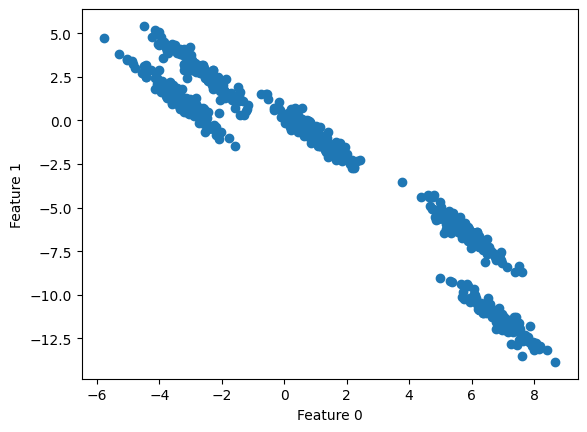

In [3]:
# Generate some random cluster data
X, y = make_blobs(random_state=170, n_samples=600, centers = 5)
rng = np.random.RandomState(74)

# Transform the data to be stretched
transformation = rng.normal(size=(2, 2))
X = np.dot(X, transformation)

# Plot
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

This is a fonction to show how your model performs.

In [4]:
def show_model_prediction(model, X):
  labels = model.fit_predict(X)
  plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis');

## Clustering algorithms from class

Please try out a few of the algorithms we used in class and in the tutorials.

You can use the code snippet below to show your model's prediction.

### Clustering Algorithm #1

Q1 [3 pts] Please describe the algorithm you intended to use and tell me why you chose it.

**Answer:**
My first thought is to use K-means clustering. I chose K-means here because the dataset is in a purely unsupervised setting (only X, no labels), and the scatter plot suggests approximately five clusters. It is also computationally efficient and easy to interpret: each cluster is summarized by a centroid.

*Describe the algorithm:*
K-means is a partitioning clustering algorithm that takes as input only the feature matrix X and a desired number of clusters k. It starts by choosing k initial centroids, then iterates two steps: 
- (1) assign each point to the nearest centroid using Euclidean distance.
- (2) recompute each centroid as the mean of the points currently assigned to that cluster. This process converges to a local minimum of the within-cluster sum of squared distances, so points inside a cluster are compact and clusters are well separated in feature space.

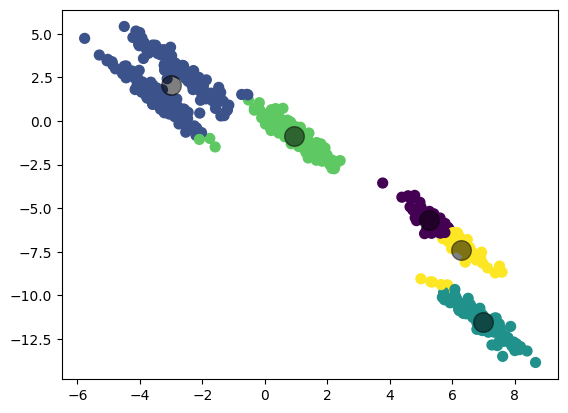

In [5]:
# Instantiate and fit your model here
from sklearn.cluster import KMeans
model_1 = KMeans(n_clusters=5, n_init='auto')
model_1.fit(X)
show_model_prediction(model_1, X)
centers = model_1.cluster_centers_ # Obtain cluster centers
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);

### Clustering Algorithm #2

Q2 [3 pts] Please describe the algorithm you intended to use and tell me why you chose it.

**Answer:**
I chose DBSCAN (Density-Based Spatial Clustering of Applications with Noise) because it defines clusters as dense regions of points separated by low-density areas. Unlike K-means, DBSCAN does not require specifying the number of clusters in advance and does not assume convex or spherical cluster shapes.

*Describe the algorithm:*

DBSCAN identifies core points based on two parameters: 
- *eps*: defines the neighborhood radius.
- *min_samples*: defines the minimum number of points required to form a dense region.
- Clusters are built by connecting neighboring core points, while points that are not density-reachable are labeled as noise (outliers). This makes DBSCAN well suited for detecting clusters of arbitrary shape and for identifying outliers in the data.

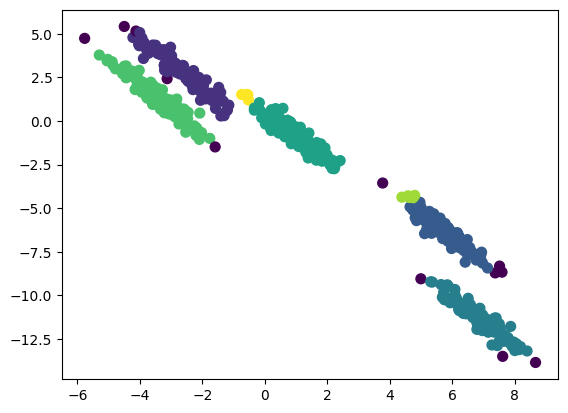

In [6]:
# Instantiate and fit your model here
from sklearn.cluster import DBSCAN 
model_2 = DBSCAN(eps=0.4, min_samples=5)
model_2.fit(X)
show_model_prediction(model_2, X)

## New clustering algorithms

Q3 [4 pts] Please try out a few of the algorithms we did not use in class. Have a look [here](https://scikit-learn.org/stable/modules/clustering.html#clustering) for inspiration.

You can use the code snippet below to show your model's prediction.

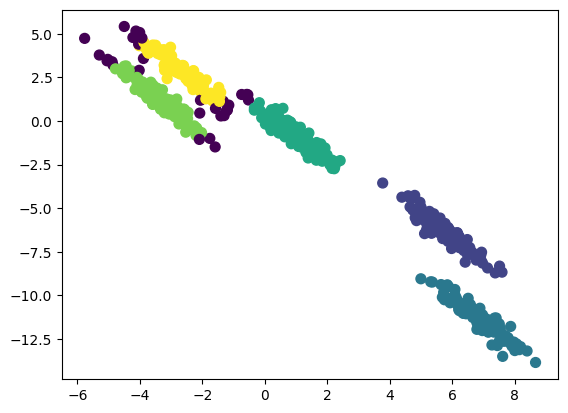

In [7]:
# Instantiate and fit your model here
import hdbscan
model_4 = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=None)
model_4.fit(X)
show_model_prediction(model_4, X)

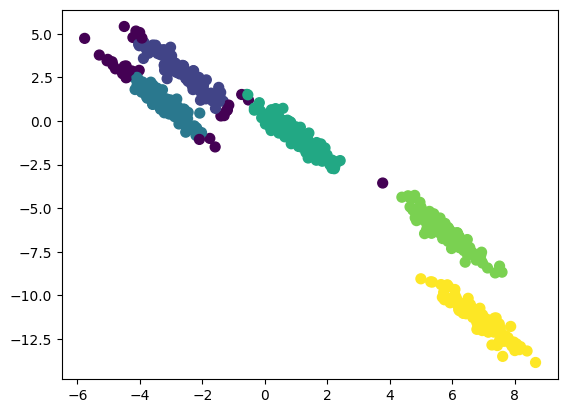

In [8]:
from sklearn.cluster import OPTICS

model_5 = OPTICS(min_samples=10, xi=0.1, min_cluster_size=0.1)
model_5.fit(X)
show_model_prediction(model_5, X)

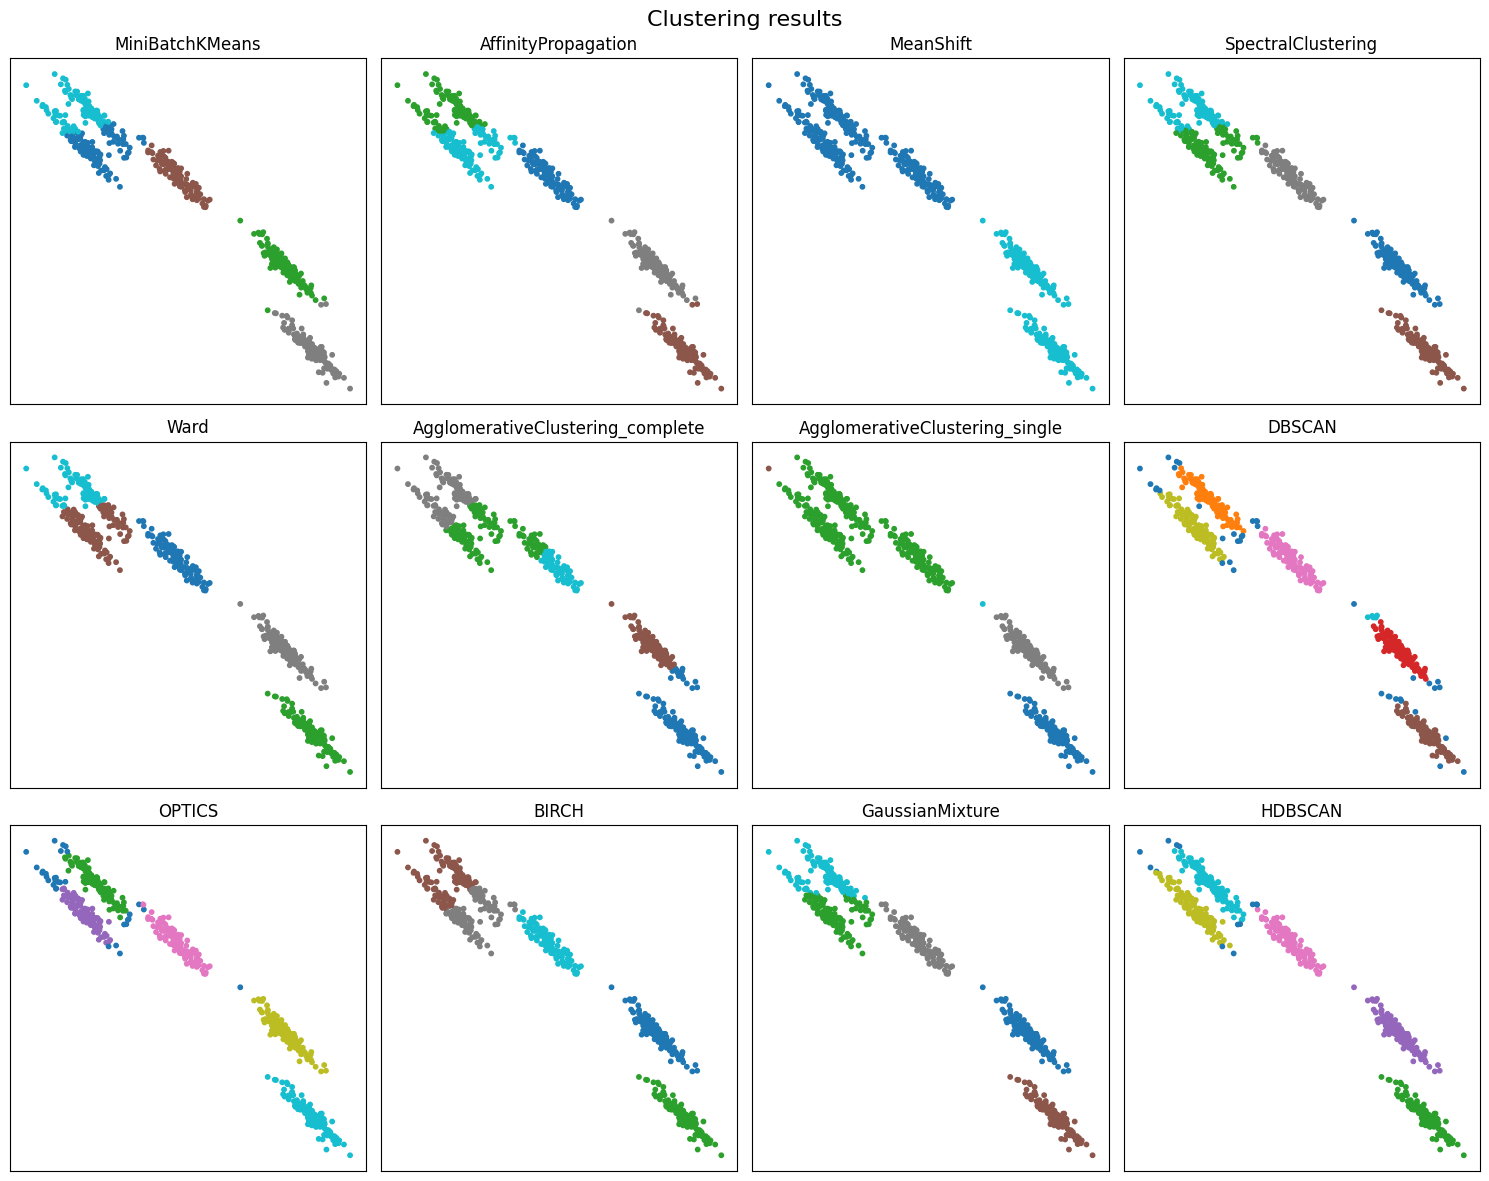

In [9]:
from sklearn.cluster import (
    MiniBatchKMeans,
    AffinityPropagation,
    MeanShift,
    SpectralClustering,
    AgglomerativeClustering,
    DBSCAN,
    OPTICS,
    Birch
)
from sklearn.mixture import GaussianMixture
import hdbscan

models = {
    "MiniBatchKMeans": MiniBatchKMeans(n_clusters=5, random_state=0, n_init=20),
    "AffinityPropagation": AffinityPropagation(damping=0.9, random_state=0, preference=-150),
    "MeanShift": MeanShift(bin_seeding=True),
    "SpectralClustering": SpectralClustering(n_clusters=5, gamma=0.5, assign_labels="kmeans", random_state=0),
    "Ward": AgglomerativeClustering(n_clusters=5, linkage="ward"),
    "AgglomerativeClustering_complete": AgglomerativeClustering(n_clusters=5, linkage="complete"),
    "AgglomerativeClustering_single": AgglomerativeClustering(n_clusters=5, linkage="single"),
    "DBSCAN": DBSCAN(eps=0.35, min_samples=5),
    "OPTICS": OPTICS(min_samples=10, xi=0.1, min_cluster_size=0.1),
    "BIRCH": Birch(threshold=0.8, n_clusters=5),
    "GaussianMixture": GaussianMixture(n_components=5, covariance_type="full", random_state=0),
    "HDBSCAN": hdbscan.HDBSCAN(min_cluster_size=40, min_samples=5)
}

results = [] 
for name, model in models.items():
    if name == "GaussianMixture":
        model.fit(X)
        labels = model.predict(X)
    else:
        model.fit(X)
        labels = model.labels_
    results.append((name, labels))

n_rows, n_cols = 3, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))
axes = axes.ravel()

for ax, (name, labels) in zip(axes, results):
    scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, s=10, cmap="tab10")
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])

for j in range(len(results), n_rows * n_cols):
    axes[j].axis("off")

fig.suptitle("Clustering results", fontsize=16)
plt.tight_layout()
plt.show()

# Wrapping up

What did you take out from this?

**Answer:**
Three points I took out from this assignment are:
1. At the first time, when I have a look [Clustering of Scikit-learn](https://scikit-learn.org/stable/modules/clustering.html), there were four clustering methods I thought that would be suitable to this data, including DBSCAN, HDBSCAN, OPTICS, Gaussian Mixture. After applying these methods and fine tuning, the results showed that DBSCAN, HDBSCAN, OPTICS could classify this data into 5 clusters, with the existence of outliers. While, Gaussian Mixture exist a part of mis-classification. I think the reason for this is that:
    - DBSCAN, HDBSCAN, and OPTICS are density-based clustering methods, which define clusters as regions of high point density separated by low-density areas. These methods are able to classify 5 clusters in the data because each cluster corresponds to a dense region in feature space, while points located at the fringes or between clusters are identified as outliers. This makes density-based approaches suited for this dataset.
    - In contrast, Gaussian Mixture Models assume that the data is generated from a mixture of Gaussian distributions and assign points to clusters by maximizing likelihood. Although GMM can model elongated clusters through full covariance matrices, it performs a soft probabilistic assignment and does not model noise or outliers. As a result, points located near cluster boundaries or in low-density regions may be assigned to neighboring clusters, leading to a small amount of misclassification.
2. After that, I tried with all other algoritms from Scikit-learn: I recognized that MiniBatchKMeans, AffinityPropagation, SpectralClustering, Ward, BIRCH, Gaussian Mixture, and Agglomerative Clustering with complete linkage share a similar classification. My thoughts are:
    - They seem to rely on a global view of the data structure, grouping points based on overall similarity, compactness, or variance rather than strictly local density.
    - Because the clusters are clearly separated and well structured, the influences of differences in their algorithms becomes less critical, resulting in similar clustering outcomes across methods. The similarity in results reflects the clarity of the data structure rather than identical algorithmic assumptions.
3. MeanShift cannot classify exactly 5 clusters, although this method can classify perfectly into 2 clusters. The result of MeanShift is similar to the result of AgglomerativeClustering (with linkage = *'single'*, n_clusters=5). The reason for this I think is that both methods rely on local criteria: density modes for MeanShift and minimum inter-point distances for single linkage. In elongated and closely spaced structures, these local criteria cause clusters to merge, resulting in fewer, larger clusters rather than well-separated groups.

*I would greatly appreciate any feedback you may have on this assignment, as it would help me improve in future work!*
